# Multi-FOV SMLM fitting

Real acquisitions are often split across several fields of view (FOVs) — separate TIFF
stacks sitting in one folder, each imaging a *different, physically unrelated* region of
the sample. `AnalysisPipeline.fit(mode="smlm")` fits every TIFF it finds in the folder,
writing one `.h5` **per file** (not one shared file) — so each FOV keeps its own,
independently-numbered set of localisations, exactly like fitting a single-FOV folder,
just repeated once per file.

**Why separate files, and why not just concatenate them afterwards**: `xc`/`yc` are local
pixel coordinates within each FOV's own field of view. If you concatenate every FOV's
localisations into one flat table and cluster across all of it, HDBSCAN has no idea the
coordinates come from unrelated physical locations — a molecule at pixel (50, 50) in FOV 1
can get merged into the same cluster as an unrelated molecule at pixel (50, 50) in FOV 2,
just because their local coordinates happen to coincide. So clustering has to run
**per FOV**, and only afterwards get concatenated back into one table (with an `fov_index`/
`fov_name` column and a running `molecular_index` offset to keep indices globally unique) —
this is exactly what the GUI's "Multi-FOV" fitting + clustering path does internally.

Data: `test_tiffs/multi_FOV_smlm/` — 3 independent FOVs (`fov1`/`fov2`/`fov3`), same dye
and simulation parameters as `01_getting_started_smlm_fitting.ipynb`'s fixture, just split
across three files instead of one.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

from pyS3M.AnalysisPipeline import AnalysisPipeline, FittingConfig
from pyS3M.Constants import AnalysisConfig
from pyS3M.clustering import ClusteringConfig

REPO_ROOT = Path.cwd().resolve().parents[1]
DATA_DIR = REPO_ROOT / "test_tiffs" / "multi_FOV_smlm"
CALIBRATION_DIR = REPO_ROOT / "Camera_Calibrations" / "Ximea_Camera"

cfg = AnalysisConfig(display=False)
pipe = AnalysisPipeline(camera="ximea", config=cfg)
pipe.load_calibration(CALIBRATION_DIR)

sorted(p.name for p in DATA_DIR.glob("*.ome.tif"))

['fov1_MMStack_Default.ome.tif',
 'fov2_MMStack_Default.ome.tif',
 'fov3_MMStack_Default.ome.tif']

## Fit — one call, one `.h5` per FOV

`mode="smlm"` fits every TIFF in the folder (this is the *same* mode used for a single FOV
in `01_getting_started_smlm_fitting.ipynb` — "multi-FOV" here just means the folder happens
to contain several files, not a different fitting mode). The return value,
`fov_data`, is a list of `(locs_df, tif_path)` pairs, one per FOV, in file order — this is
also exactly what `AnalysisPipeline.load_localisations_per_fov(folder)` returns if you want
to reload later without re-fitting.

In [2]:
fc = FittingConfig(peak_wavelength=0.685, pfa=1e-3)
fov_data = pipe.fit(DATA_DIR, mode="smlm", fitting_config=fc)

for tif, (locs_df, tif_path) in zip(sorted(DATA_DIR.glob("*.ome.tif")), fov_data):
    print(f"{tif.name}: {len(locs_df)} localisations")

Detecting puncta:   0%|          | 0/50 [00:00<?, ?it/s]

Detecting puncta:   0%|          | 0/50 [00:00<?, ?it/s]

Detecting puncta:   0%|          | 0/50 [00:00<?, ?it/s]

fov1_MMStack_Default.ome.tif: 42 localisations
fov2_MMStack_Default.ome.tif: 26 localisations
fov3_MMStack_Default.ome.tif: 42 localisations


## Filter & cluster — per FOV, then combine

Same STORM-modality reasoning as the getting-started notebook: `min_cluster_size` needs to
be small since each site only blinks a handful of times before bleaching.

Each FOV is filtered and clustered independently via `filter_and_cluster` (never mixing
coordinates across FOVs), then tagged with `fov_index`/`fov_name` and concatenated — with
`molecular_index` offset by a running total so it stays globally unique across all FOVs,
not just within one.

In [3]:
cc = ClusteringConfig(min_cluster_size=2)

sm_parts, sf_parts = [], []
molecular_index_offset = 0
for fov_idx, (fov_locs, tif_path) in enumerate(fov_data):
    fov_name = Path(tif_path).stem if tif_path else f"fov_{fov_idx}"
    sm_fov, sf_fov = pipe.filter_and_cluster(fov_locs, clustering_config=cc)
    if sm_fov.empty:
        continue
    sm_fov = sm_fov.assign(
        fov_index=fov_idx, fov_name=fov_name,
        molecular_index=sm_fov["molecular_index"] + molecular_index_offset,
    )
    sf_fov = sf_fov.assign(
        fov_index=fov_idx, fov_name=fov_name,
        molecular_index=sf_fov["molecular_index"] + molecular_index_offset,
    )
    sm_parts.append(sm_fov)
    sf_parts.append(sf_fov)
    molecular_index_offset = int(sm_fov["molecular_index"].max()) + 1

sm_db = pd.concat(sm_parts, ignore_index=True)
sf_db = pd.concat(sf_parts, ignore_index=True)
print(f"{len(sm_db)} molecules from {len(sf_db)} quality-filtered localisations, across {sm_db['fov_name'].nunique()} FOVs")
sm_db.groupby("fov_name").size()

5 molecules from 24 quality-filtered localisations, across 2 FOVs


fov_name
fov1_MMStack_Default.ome    3
fov3_MMStack_Default.ome    2
dtype: int64

## Render, one panel per FOV

/tmp/ipykernel_3613737/2554895313.py:11: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


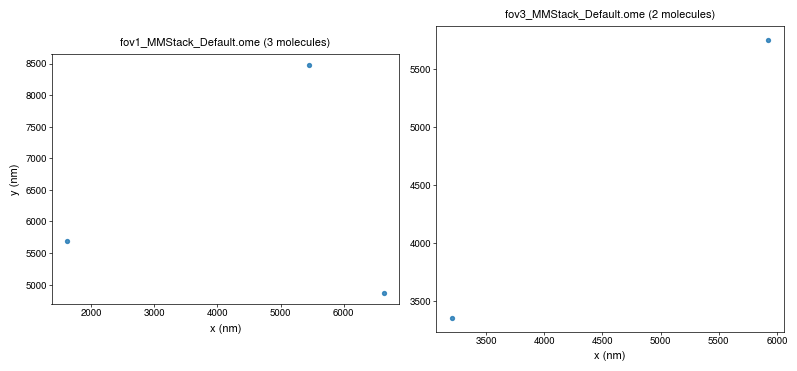

In [4]:
pixel_size_nm = pipe.pixel_size * 1000.0
fov_names = sorted(sm_db["fov_name"].unique())
fig, axes = plt.subplots(1, len(fov_names), figsize=(4 * len(fov_names), 4), squeeze=False)
for ax, fov in zip(axes[0], fov_names):
    sub = sm_db[sm_db["fov_name"] == fov]
    ax.scatter(sub["xc"] * pixel_size_nm, sub["yc"] * pixel_size_nm, s=8, alpha=0.8)
    ax.set_aspect("equal")
    ax.set_title(f"{fov} ({len(sub)} molecules)")
    ax.set_xlabel("x (nm)")
axes[0][0].set_ylabel("y (nm)")
plt.tight_layout()
plt.show()

## Next: `03_drift_correction.ipynb`